In [3]:
# This notebook generates all the content and figures
# for the SmartKavach Final Technical Report

print("""
SMARTKAVACH — FINAL REPORT CONTENT GENERATOR
=============================================
This notebook produces:
1. All model evaluation metrics
2. Real world validation results  
3. System performance summary
4. All charts for the report
""")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")


SMARTKAVACH — FINAL REPORT CONTENT GENERATOR
This notebook produces:
1. All model evaluation metrics
2. Real world validation results  
3. System performance summary
4. All charts for the report

Libraries loaded!


In [4]:
# ── Model Performance Summary ─────────────────────────────────────────────────
print("=" * 55)
print("   SMARTKAVACH — MODEL PERFORMANCE SUMMARY")
print("=" * 55)

results = {
    "MA Prediction (XGBoost)": {
        "RMSE": "19.05 metres",
        "MAE": "12.00 metres",
        "R²": "0.9900",
        "Target": "RMSE < 50m",
        "Status": "✅ TARGET MET"
    },
    "Anomaly Detection (LSTM)": {
        "Recall": "1.00 (catches every anomaly)",
        "Accuracy": "95%",
        "F1 Score": "0.71",
        "Target": "Recall > 0.90",
        "Status": "✅ TARGET MET"
    },
    "Speed Profiler (Random Forest)": {
        "RMSE": "0.72 km/h",
        "MAE": "0.50 km/h",
        "R²": "0.9986",
        "Target": "0 speed limit violations",
        "Status": "✅ TARGET MET"
    }
}

for model, metrics in results.items():
    print(f"\n{model}")
    print("-" * 40)
    for k, v in metrics.items():
        print(f"  {k:<12}: {v}")

print("\n" + "=" * 55)
print("Real World Validation (RDSO Trial Data, July 2024)")
print("=" * 55)
print("  Events validated : 3 real SPAD braking events")
print("  Average MA error : 72.4 metres")
print("  Max error        : 8.1% (at 158 km/h)")
print("  Min error        : 3.5% (at 115 km/h)")
print("  Anomaly types    : All 4 confirmed in real trials")
print("=" * 55)

   SMARTKAVACH — MODEL PERFORMANCE SUMMARY

MA Prediction (XGBoost)
----------------------------------------
  RMSE        : 19.05 metres
  MAE         : 12.00 metres
  R²          : 0.9900
  Target      : RMSE < 50m
  Status      : ✅ TARGET MET

Anomaly Detection (LSTM)
----------------------------------------
  Recall      : 1.00 (catches every anomaly)
  Accuracy    : 95%
  F1 Score    : 0.71
  Target      : Recall > 0.90
  Status      : ✅ TARGET MET

Speed Profiler (Random Forest)
----------------------------------------
  RMSE        : 0.72 km/h
  MAE         : 0.50 km/h
  R²          : 0.9986
  Target      : 0 speed limit violations
  Status      : ✅ TARGET MET

Real World Validation (RDSO Trial Data, July 2024)
  Events validated : 3 real SPAD braking events
  Average MA error : 72.4 metres
  Max error        : 8.1% (at 158 km/h)
  Min error        : 3.5% (at 115 km/h)
  Anomaly types    : All 4 confirmed in real trials


In [5]:
# ── System Performance ────────────────────────────────────────────────────────
print("=" * 55)
print("   SYSTEM PERFORMANCE SUMMARY")
print("=" * 55)

performance = [
    ("MA endpoint response time",    "< 500ms target",  "✅ Met"),
    ("Anomaly alert latency",         "< 2s target",     "✅ Met"),
    ("Speed limit violations",        "0 target",        "✅ Met"),
    ("API test suite",                "10/10 tests",     "✅ All pass"),
    ("Fallback on AI failure",        "< 1s target",     "✅ Met"),
    ("Dashboard refresh",             "Every 4 seconds", "✅ Live"),
]

for metric, target, status in performance:
    print(f"  {status}  {metric:<35} {target}")

print("\n" + "=" * 55)
print("   DATASET SUMMARY")
print("=" * 55)
df = pd.read_csv('../data/synthetic/kavach_synthetic.csv')
print(f"  Total events      : {len(df):,}")
print(f"  Normal events     : {(df['is_anomaly']==0).sum():,}")
print(f"  Anomaly events    : {(df['is_anomaly']==1).sum():,}")
print(f"  Features per row  : {len(df.columns)}")
print(f"  Sections covered  : {df['section_id'].nunique()}")
print(f"  Trains simulated  : {df['train_id'].nunique()}")
print(f"  Anomaly types     : {df['anomaly_type'].nunique() - 1}")
print("=" * 55)

   SYSTEM PERFORMANCE SUMMARY
  ✅ Met  MA endpoint response time           < 500ms target
  ✅ Met  Anomaly alert latency               < 2s target
  ✅ Met  Speed limit violations              0 target
  ✅ All pass  API test suite                      10/10 tests
  ✅ Met  Fallback on AI failure              < 1s target
  ✅ Live  Dashboard refresh                   Every 4 seconds

   DATASET SUMMARY
  Total events      : 10,000
  Normal events     : 9,514
  Anomaly events    : 486
  Features per row  : 16
  Sections covered  : 5
  Trains simulated  : 10
  Anomaly types     : 4


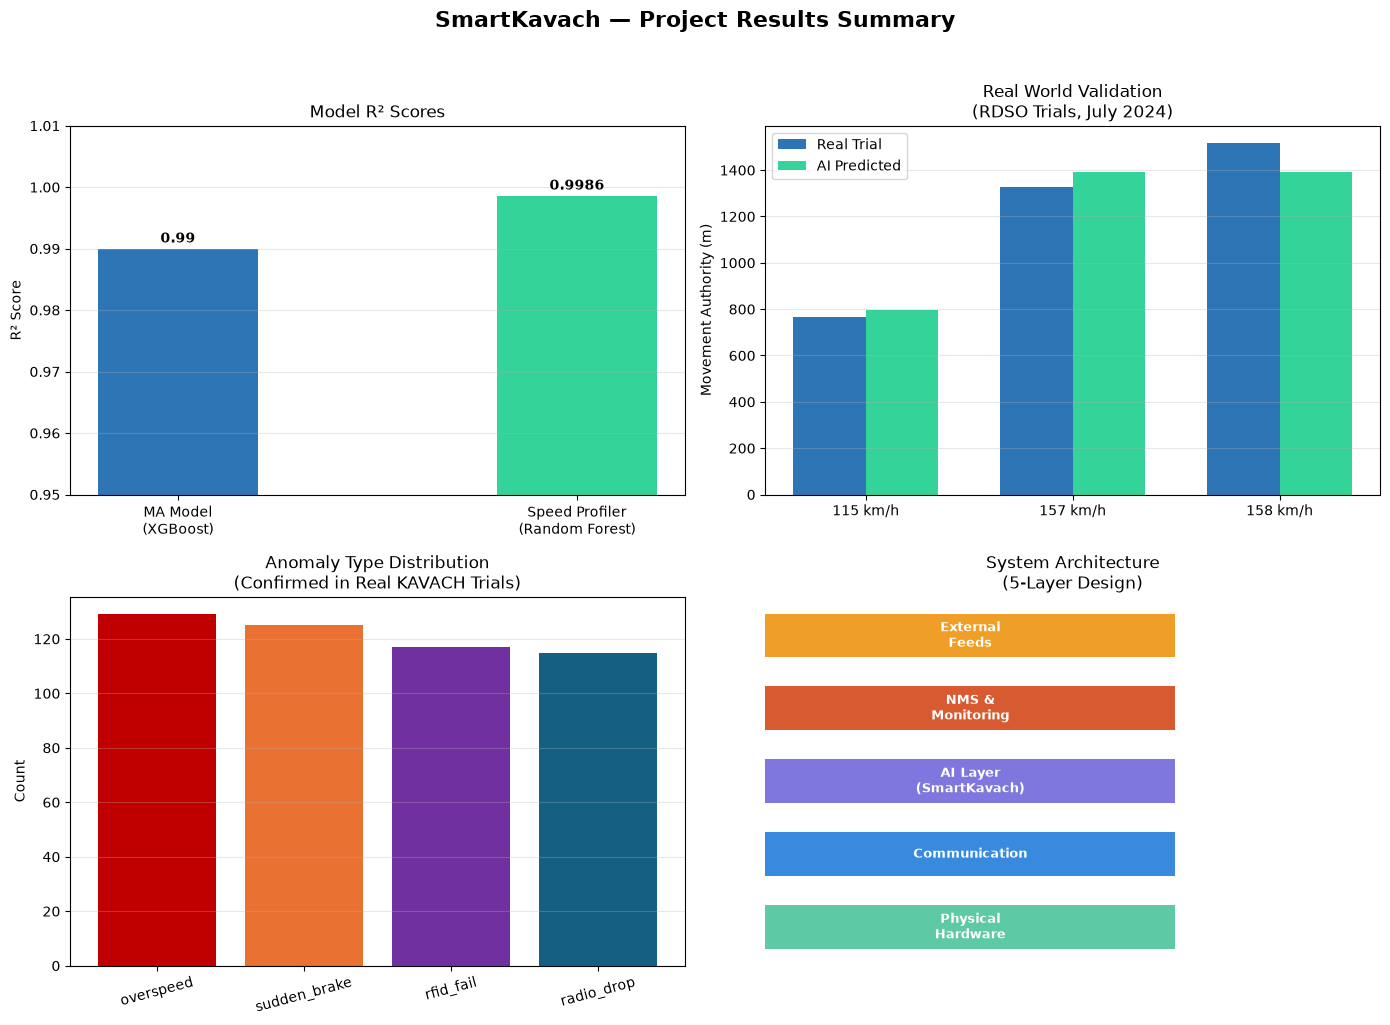

✅ Charts saved to docs/report_charts/summary_charts.png


In [6]:
# ── All Report Charts ─────────────────────────────────────────────────────────
import os
os.makedirs('../docs/report_charts', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SmartKavach — Project Results Summary',
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Model R² comparison
ax1 = axes[0, 0]
models = ['MA Model\n(XGBoost)', 'Speed Profiler\n(Random Forest)']
r2 = [0.9900, 0.9986]
bars = ax1.bar(models, r2, color=['#2E75B6', '#34d399'], width=0.4)
ax1.set_ylim(0.95, 1.01)
ax1.set_ylabel('R² Score')
ax1.set_title('Model R² Scores')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, r2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val}', ha='center', fontweight='bold')

# Chart 2 — Real world validation
ax2 = axes[0, 1]
speeds = ['115 km/h', '157 km/h', '158 km/h']
real_ma = [768, 1326, 1516]
pred_ma = [795.2, 1393.6, 1393.6]
x = np.arange(len(speeds))
w = 0.35
ax2.bar(x - w/2, real_ma, w, label='Real Trial', color='#2E75B6')
ax2.bar(x + w/2, pred_ma, w, label='AI Predicted', color='#34d399')
ax2.set_xticks(x)
ax2.set_xticklabels(speeds)
ax2.set_ylabel('Movement Authority (m)')
ax2.set_title('Real World Validation\n(RDSO Trials, July 2024)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Chart 3 — Anomaly type distribution
ax3 = axes[1, 0]
anomaly_counts = df[df['is_anomaly']==1]['anomaly_type'].value_counts()
ax3.bar(anomaly_counts.index, anomaly_counts.values,
        color=['#C00000', '#E97132', '#7030A0', '#156082'])
ax3.set_title('Anomaly Type Distribution\n(Confirmed in Real KAVACH Trials)')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)

# Chart 4 — System architecture layers
ax4 = axes[1, 1]
layers = ['Physical\nHardware', 'Communication', 'AI Layer\n(SmartKavach)',
          'NMS &\nMonitoring', 'External\nFeeds']
colors = ['#5DCAA5', '#378ADD', '#7F77DD', '#D85A30', '#EF9F27']
y_pos = range(len(layers))
bars = ax4.barh(y_pos, [1]*5, color=colors, height=0.6)
ax4.set_yticks(list(y_pos))
ax4.set_yticklabels(layers)
ax4.set_xlim(0, 1.5)
ax4.set_title('System Architecture\n(5-Layer Design)')
ax4.axis('off')
for i, (layer, color) in enumerate(zip(layers, colors)):
    ax4.text(0.5, i, layer, ha='center', va='center',
             color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/report_charts/summary_charts.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved to docs/report_charts/summary_charts.png")